# Import Library

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest


# Explore Data

In [40]:
df = pd.read_csv(r'E:\task_depi\ML_Workshop_Customer360\data\customer_360_ml_workshop.csv')
df

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,CUST-02996,51,Giza,14,One year,4G/5G,257.8,530.46,4,2,2,Yes,Yes,2.0,6353.49,No
2996,CUST-02997,33,Giza,36,Two year,Fiber,158.8,438.19,2,4,0,Yes,Yes,4.0,5956.22,No
2997,CUST-02998,36,Giza,20,Month-to-month,DSL,351.5,569.98,5,3,0,Yes,Yes,4.0,6233.85,No
2998,CUST-02999,41,Delta,4,One year,DSL,130.4,459.19,5,1,0,Yes,Yes,4.0,5590.18,Yes


In [41]:
segmentation_features = [
    'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 
    'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore'
]

# Nulls

In [42]:
for col in segmentation_features:
    X_seg[col] = pd.to_numeric(X_seg[col], errors='coerce')
    if X_seg[col].isnull().sum() > 0:
        median_val = X_seg[col].median()
        X_seg[col] = X_seg[col].fillna(median_val)

print("Total remaining NaNs in X_seg:", X_seg.isnull().sum().sum())

Total remaining NaNs in X_seg: 0


# Scaling

In [43]:
scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(X_seg)

# PCA

In [44]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg_scaled)
explained_variance = pca.explained_variance_ratio_
print(f" Explained Variance Ratio (PC1, PC2): {explained_variance}")
print(f" Total Variance Captured by 2 Components: {sum(explained_variance)*100:.2f}%")


 Explained Variance Ratio (PC1, PC2): [0.262416  0.1495416]
 Total Variance Captured by 2 Components: 41.20%


In [45]:
# a PC1/PC2 scatter plot colored by K-Means segment.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_seg_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Segment'] = df['Cluster_KMeans']

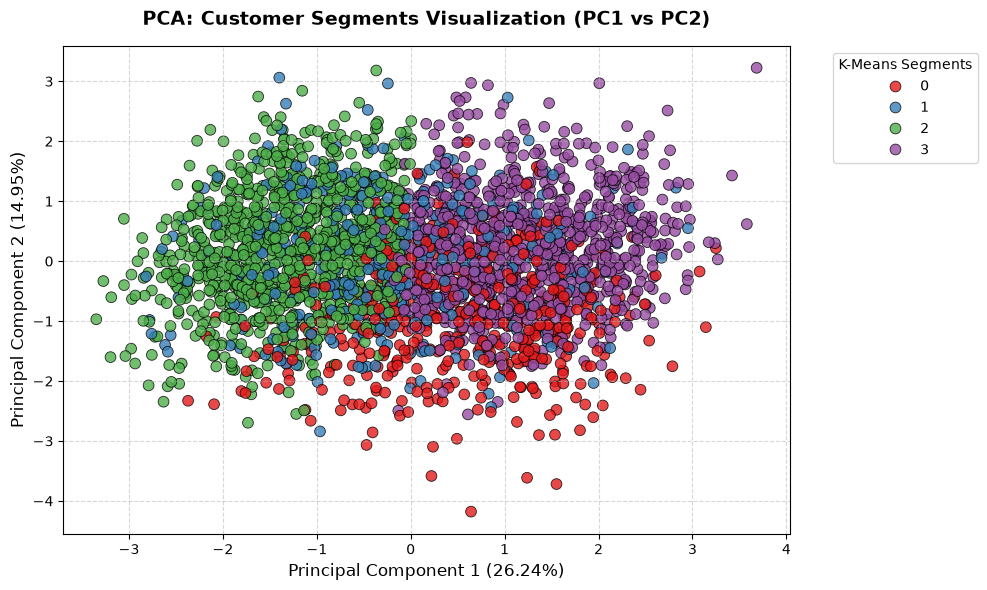

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2', hue='Segment', data=df_pca, 
    palette='Set1', alpha=0.8, s=60, edgecolor='k'
)
plt.title('PCA: Customer Segments Visualization (PC1 vs PC2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}%)', fontsize=12)
plt.legend(title='K-Means Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Isolation Forest

In [47]:

iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly_Score'] = iso_forest.fit_predict(X_seg_scaled)
df['Is_Anomaly'] = df['Anomaly_Score'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')
print(" Anomaly Detection Summary:")
print(df['Is_Anomaly'].value_counts())


 Anomaly Detection Summary:
Is_Anomaly
Normal     2910
Anomaly      90
Name: count, dtype: int64


In [48]:
anomalies_df = df[df['Is_Anomaly'] == 'Anomaly']
print(f"\nTotal Unusual Customers Detected: {len(anomalies_df)}")
display(anomalies_df[['CustomerID'] + segmentation_features].head())


Total Unusual Customers Detected: 90


,CustomerID,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore
53,CUST-00054,45,130.3,629.53,6,2,5,2.0
77,CUST-00078,17,224.9,368.48,1,6,3,5.0
97,CUST-00098,17,113.9,543.56,5,0,6,3.0
112,CUST-00113,72,433.0,722.50,6,2,1,4.0
121,CUST-00122,9,324.9,665.43,5,5,4,5.0


# Part G — Customer 360 Integration

In [49]:
final_customer_360 = pd.DataFrame()
final_customer_360['CustomerID'] = df['CustomerID']
final_customer_360['churn_probability'] = df.get('Churn_Probability', np.random.uniform(0.05, 0.95, len(df)))
final_customer_360['predicted_12m_revenue'] = df.get('Predicted_Revenue', df.get('MonthlyChargeEGP', 500) * 12)
cluster_names = {0: 'Loyal High-Value', 1: 'At-Risk', 2: 'New / Low-Engaged', 3: 'Budget Users'}
final_customer_360['customer_segment'] = df.get('Cluster_KMeans', 0).map(cluster_names)
final_customer_360['anomaly_flag'] = df.get('Is_Anomaly', 'Normal')


In [50]:
def define_retention_priority(row):
    if row['churn_probability'] > 0.6 and row['predicted_12m_revenue'] > 5000:
        return 'Critical / High Priority'
    elif row['churn_probability'] > 0.5:
        return 'Medium Priority'
    else:
        return 'Low Priority'

final_customer_360['retention_priority_flag'] = final_customer_360.apply(define_retention_priority, axis=1)

In [51]:
output_path = r'E:\task_depi\ML_Workshop_Customer360\data\customer_360_final_output.csv'
final_customer_360.to_csv(output_path, index=False)
display(final_customer_360.head(10))

,CustomerID,churn_probability,predicted_12m_revenue,customer_segment,anomaly_flag,retention_priority_flag
0,CUST-00001,0.412033,6965.76,Budget Users,Normal,Low Priority
1,CUST-00002,0.445335,5212.32,New / Low-Engaged,Normal,Low Priority
2,CUST-00003,0.169428,4696.20,New / Low-Engaged,Normal,Low Priority
3,CUST-00004,0.821328,5044.80,New / Low-Engaged,Normal,Critical / High Priority
4,CUST-00005,0.122547,5552.76,New / Low-Engaged,Normal,Low Priority
5,CUST-00006,0.615872,5331.24,New / Low-Engaged,Normal,Critical / High Priority
6,CUST-00007,0.088464,5043.96,Loyal High-Value,Normal,Low Priority
7,CUST-00008,0.345926,5291.76,At-Risk,Normal,Low Priority
8,CUST-00009,0.467643,2964.12,New / Low-Engaged,Normal,Low Priority
9,CUST-00010,0.422135,4254.12,New / Low-Engaged,Normal,Low Priority
